In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Titanic/train.csv')
df.shape
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df = df.drop(columns=['Name', 'Ticket', 'Cabin'])
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,male,22.0,1,0,7.2500,S
1,2,1,1,female,38.0,1,0,71.2833,C
2,3,1,3,female,26.0,0,0,7.9250,S
3,4,1,1,female,35.0,1,0,53.1000,S
4,5,0,3,male,35.0,0,0,8.0500,S


In [4]:
df.isnull().sum()
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
dtype: int64

In [5]:
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,1,0,3,0,22.0,1,0,7.2500,False,True
1,2,1,1,1,38.0,1,0,71.2833,False,False
2,3,1,3,1,26.0,0,0,7.9250,False,True
3,4,1,1,1,35.0,1,0,53.1000,False,True
4,5,0,3,0,35.0,0,0,8.0500,False,True


In [6]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=['Survived'])
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [7]:
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

rf = RandomForestClassifier(n_estimators=500, max_depth=None, random_state=20)
rf.fit(X_train, y_train)
pred1 = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, pred1)
precision = precision_score(y_test, pred1)
recall = recall_score(y_test, pred1)
f1 = f1_score(y_test, pred1)

print(f"Accuracy:  {rf_accuracy*100:.3f}%")
print(f"Precision: {precision*100:.3f}%")
print(f"Recall:    {recall*100:.3f}%")
print(f"F1 Score:  {f1*100:.3f}%")

Accuracy:  82.123%
Precision: 80.882%
Recall:    74.324%
F1 Score:  77.465%


In [8]:
et = ExtraTreesClassifier(n_estimators=1000, max_depth=None, random_state=42)
et.fit(X_train, y_train)
pred2 = et.predict(X_test)

et_accuracy = accuracy_score(y_test, pred2)
precision = precision_score(y_test, pred2)
recall = recall_score(y_test, pred2)
f1 = f1_score(y_test, pred2)

print(f"Accuracy:  {et_accuracy*100:.3f}%")
print(f"Precision: {precision*100:.3f}%")
print(f"Recall:    {recall*100:.3f}%")
print(f"F1 Score:  {f1*100:.3f}%")

Accuracy:  84.916%
Precision: 83.099%
Recall:    79.730%
F1 Score:  81.379%


In [9]:
test_df = pd.read_csv('Titanic/test.csv')
test_df.shape
test_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [10]:
test_df = test_df.drop(['Name', 'Ticket', 'Cabin'], axis=1)
test_df.isnull().sum()

PassengerId     0
Pclass          0
Sex             0
Age            86
SibSp           0
Parch           0
Fare            1
Embarked        0
dtype: int64

In [11]:
test_df['Age'] = test_df['Age'].fillna(test_df['Age'].median())
test_df['Fare'] = test_df['Fare'].fillna(test_df['Fare'].median())

In [12]:
test_df.isnull().sum()

PassengerId    0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
dtype: int64

In [13]:
test_df = pd.get_dummies(test_df, columns=['Embarked'], drop_first=True)
test_df['Sex'] = test_df['Sex'].map({'male': 0, 'female': 1})
test_df.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,892,3,0,34.5,0,0,7.8292,True,False
1,893,3,1,47.0,1,0,7.0000,False,True
2,894,2,0,62.0,0,0,9.6875,True,False
3,895,3,0,27.0,0,0,8.6625,False,True
4,896,3,1,22.0,1,1,12.2875,False,True


In [14]:
predictions = rf.predict(test_df)

In [15]:
submission = pd.DataFrame({
    'Passenger ID': test_df['PassengerId'],
    'Survived': predictions
}
)

submission.to_csv('submission.csv', index=False)
submission.head()

,Passenger ID,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0


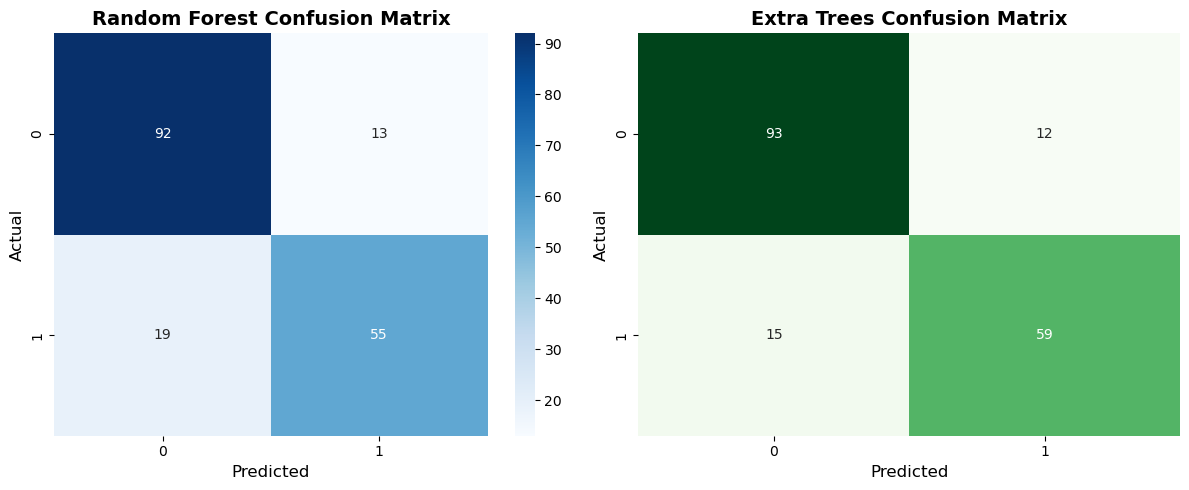

In [16]:
rf_cm = confusion_matrix(y_test, pred1)
et_cm = confusion_matrix(y_test, pred2)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=True)
axes[0].set_title('Random Forest Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('Actual', fontsize=12)


sns.heatmap(et_cm, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False)
axes[1].set_title('Extra Trees Confusion Matrix', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted', fontsize=12)
axes[1].set_ylabel('Actual', fontsize=12)

plt.tight_layout()
plt.show()

In [17]:
!pip install xgboost lightgbm catboost -q --root-user-action=ignore
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

In [18]:
xgb_model = xgb.XGBClassifier(n_estimators = 50, learning_rate = 0.1, max_depth=5, random_state=20)
xgb_model.fit(X_train, y_train)
xgpred = xgb_model.predict(X_test)

xg_accuracy = accuracy_score(y_test, xgpred)
print(f"Accuracy for XgBoost model is: {xg_accuracy*100:.3f}%")

Accuracy for XgBoost model is: 82.123%


In [19]:
lgb_model = lgb.LGBMClassifier(n_estimators=50, learning_rate=0.1, max_depth=5, random_state=20, verbose=-1, force_col_wise=True)
lgb_model.fit(X_train, y_train)
lgbpredict = lgb_model.predict(X_test)

lgb_accuracy = accuracy_score(y_test, lgbpredict)
print(f"Accuracy for LGBM model is: {lgb_accuracy*100:.3f}%")

Accuracy for LGBM model is: 80.447%


In [20]:
cat_model = CatBoostClassifier(iterations=50, learning_rate=0.1, depth=5, random_state=42, verbose=0)
cat_model.fit(X_train, y_train)
catpredict = cat_model.predict(X_test)

cat_accuracy = accuracy_score(y_test, catpredict)
print(f"Accuracy for CatBoost model is: {cat_accuracy*100:.3f}%")

Accuracy for CatBoost model is: 82.123%


In [26]:
results = pd.DataFrame({
    'Model': ['RandomForestClassifier', 'ExtraTreesClassifier', 'XGBoost', 'LightGBM', 'CatBoost'],
    'Accuracy': [rf_accuracy, et_accuracy, xg_accuracy, lgb_accuracy, cat_accuracy]
})

results = results.sort_values('Accuracy', ascending=False)
print("\nMODEL COMPARISON\n")
print(results.head())
print(f"\nBest model for this dataset is {results.iloc[0]['Model']} for which the accuracy is {results.iloc[0]['Accuracy']*100:.3f}%")


MODEL COMPARISON

                    Model  Accuracy
1    ExtraTreesClassifier  0.849162
0  RandomForestClassifier  0.821229
2                 XGBoost  0.821229
4                CatBoost  0.821229
3                LightGBM  0.804469

Best model for this dataset is ExtraTreesClassifier for which the accuracy is 84.916%


In [28]:
from sklearn.ensemble import VotingClassifier

voting_model = VotingClassifier(
    estimators=[
        ('xgb', xgb.XGBClassifier(n_estimators = 50, learning_rate = 0.1, max_depth=5, random_state=20)),
        ('lgb', lgb.LGBMClassifier(n_estimators=50, learning_rate=0.1, max_depth=5, random_state=20, verbose=-1, force_col_wise=True)),
        ('cat', CatBoostClassifier(iterations=50, learning_rate=0.1, depth=5, random_state=42, verbose=0))
],
    voting='soft'
)

voting_model.fit(X_train, y_train)
voting_pred = voting_model.predict(X_test)

voting_accuracy = accuracy_score(y_test, voting_pred)
print(f"Accuracy of the VotingClassifier is {voting_accuracy*100:.3f}%")

Accuracy of the VotingClassifier is 82.123%
